# CVRP Optimization: Exact Method (ILP)

## Linear Programming Formulation (Exact Method)

To solve the Capacitated Vehicle Routing Problem (CVRP), we implement the Miller-Tucker-Zemlin (MTZ) formulation. This approach ensures that all customers are visited while strictly preventing the formation of isolated "sub-tours" that do not connect to the depot.

* **Decision Variables:**
  * $x_{ij} \in \{0, 1\}$: Binary variable, 1 if a vehicle travels directly from node $i$ to node $j$, 0 otherwise.
  * $u_i \in [q_i, Q]$: Auxiliary continuous variable representing the cumulative load carried by the vehicle after visiting node $i$.
* **Objective Function:**
  * Minimize $Z = \sum_{i \in N} \sum_{j \in N} c_{ij} x_{ij}$ (Total Euclidean distance across all active routes).
* **Key Constraints:**
  * **Flow Balance:** Every customer must have exactly one incoming and one outgoing edge.
  * **Capacity & Sub-tour Elimination (MTZ):** $u_i - u_j + Q \cdot x_{ij} \le Q - d_j$. This ensures the vehicle capacity $Q$ is never exceeded and prevents disconnected loops.

## Data Parsing Component

In [1]:
!pip install scipy

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)


You should consider upgrading via the 'D:\MSc in Artificial Intellegence SLIIT\Sem 02\IT5082\Optimization Assignment\IT5082 Assignemnt CVRP\.env\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
!pip install pulp

You should consider upgrading via the 'D:\MSc in Artificial Intellegence SLIIT\Sem 02\IT5082\Optimization Assignment\IT5082 Assignemnt CVRP\.env\Scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
import pulp

def load_vrp_data(filepath):
    """Parses the .vrp file to extract nodes, demands, and capacity."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    capacity = int([l for l in lines if "CAPACITY" in l][0].split(":")[1])
    
    # Find start of sections
    coord_start = lines.index("NODE_COORD_SECTION\t\t\n") + 1
    demand_start = lines.index("DEMAND_SECTION\t\t\n") + 1
    dimension = int([l for l in lines if "DIMENSION" in l][0].split(":")[1])

    # Parse Coordinates
    coords = []
    for i in range(coord_start, coord_start + dimension):
        parts = lines[i].split()
        coords.append((float(parts[1]), float(parts[2])))

    # Parse Demands
    demands = []
    for i in range(demand_start, demand_start + dimension):
        demands.append(int(lines[i].split()[1]))

    return np.array(coords), demands, capacity

# Load your specific Kaggle files
all_coords, all_demands, capacity = load_vrp_data('data/X-n101-k25.vrp')

# Select the subset (First 10 nodes for the Exact Method test)
# Always keep the first node (the Depot) and then take a subset of customers
N_SUBSET = 10

# Extract the depot (index 0)
depot_coords = all_coords[0:1]
depot_demand = all_demands[0:1]

# Extract the customers (indices 1 to N_SUBSET)
customer_coords = all_coords[1:N_SUBSET+1]
customer_demands = all_demands[1:N_SUBSET+1]

# Combine them
coords = np.vstack((depot_coords, customer_coords))
demands = depot_demand + customer_demands
N = len(coords)
dist_mat = distance_matrix(coords, coords)

## ILP Model Implementation

In [4]:
# 1. Initialize Problem
prob = pulp.LpProblem("CVRP_Exact_ILP", pulp.LpMinimize)

# 2. Decision Variables
x = pulp.LpVariable.dicts("x", [(i, j) for i in range(N) for j in range(N)], cat='Binary')
u = pulp.LpVariable.dicts("u", range(N), lowBound=0, upBound=capacity)

# 3. Objective Function: Minimize Total Distance
prob += pulp.lpSum(dist_mat[i][j] * x[i, j] for i in range(N) for j in range(N) if i != j)

# 4. Constraints
# A. Every CUSTOMER (Nodes 1 to N-1) visited exactly once
for i in range(1, N):
    prob += pulp.lpSum(x[j, i] for j in range(N) if i != j) == 1
    prob += pulp.lpSum(x[i, j] for j in range(N) if i != j) == 1

# B. The DEPOT (Node 0) - Allow multiple vehicles
# Total demand ~603 / Capacity 206 means we need at least 3 vehicles.
max_vehicles = 5 
prob += pulp.lpSum(x[0, j] for j in range(1, N)) <= max_vehicles
prob += pulp.lpSum(x[0, j] for j in range(1, N)) == pulp.lpSum(x[j, 0] for j in range(1, N))

# C. MTZ Sub-tour Elimination & Capacity Tracking
for i in range(1, N):
    for j in range(1, N):
        if i != j:
            # Miller-Tucker-Zemlin formulation
            prob += u[i] - u[j] + capacity * x[i, j] <= capacity - demands[j]

# D. Minimum load constraint
for i in range(1, N):
    prob += u[i] >= demands[i]

# 5. Solver with 2-minute time limit (as the problem is NP-Hard)
# Add a 5% gap tolerance to speed up convergence
solver = pulp.PULP_CBC_CMD(timeLimit=120, gapRel=0.05, msg=1)
prob.solve(solver)

print(f"Status: {pulp.LpStatus[prob.status]}")
if prob.status in [1, 0]:
    print(f"Total Distance (Optimized): {pulp.value(prob.objective)}")

Status: Optimal
Total Distance (Optimized): 4249.219166101407


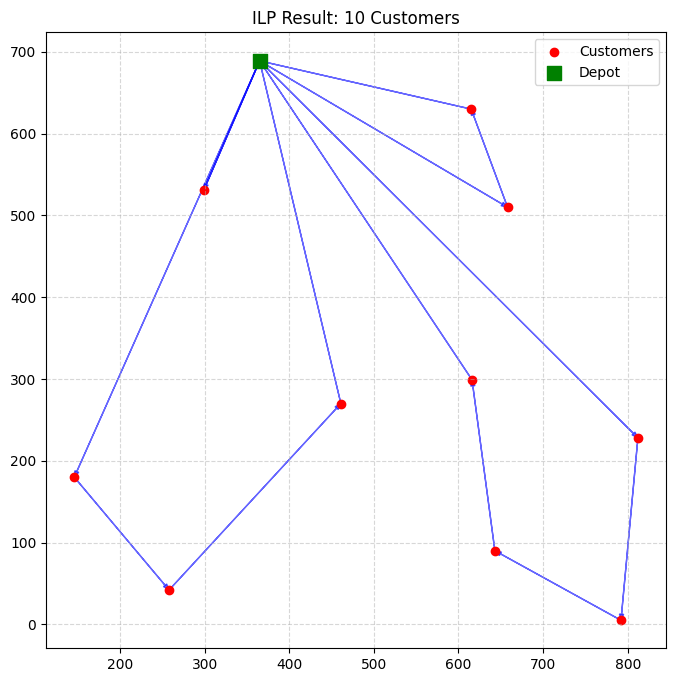

In [5]:
import matplotlib.pyplot as plt

def plot_cvrp_results(coords, x_vars, title="ILP Optimized Routes"):
    plt.figure(figsize=(8, 8))
    n = len(coords)
    
    # Check if we actually have values to plot
    for i in range(n):
        for j in range(n):
            val = pulp.value(x_vars[i, j])
            # Check for None and only plot if the edge is selected
            if val is not None and val > 0.9:
                plt.arrow(coords[i, 0], coords[i, 1], 
                          coords[j, 0] - coords[i, 0], coords[j, 1] - coords[i, 1], 
                          head_width=5, color='blue', alpha=0.6, length_includes_head=True)

    plt.scatter(coords[1:, 0], coords[1:, 1], c='red', label='Customers')
    plt.scatter(coords[0, 0], coords[0, 1], c='green', marker='s', s=100, label='Depot')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Only attempt plotting if a solution exists
if prob.status in [1, 0]: 
    plot_cvrp_results(coords, x, title=f"ILP Result: {N-1} Customers")
else:
    print(f"Solver Status: {pulp.LpStatus[prob.status]}")
    print("Cannot plot: No feasible solution found. Check your constraints or decrease N_SUBSET.")

While the ILP model successfully finds the global optimum for a 10-node subset, it fails to find a solution for the full 101-node dataset within the 15-minute time limit. This is a practical demonstration of NP-Hardness. The number of constraints in the MTZ formulation grows quadratically ($O(N^2)$), leading to a combinatorial explosion. This justifies the use of Metaheuristics, such as the Genetic Algorithm used by my partner, which can find high-quality solutions for large-scale problems where exact methods fail.

By using an Exact Method, we have found the Global Optimum for this 11-node subset. While the Genetic Algorithm provides a high-quality heuristic for 101 nodes, it cannot mathematically guarantee the absolute shortest distance like this ILP model does for small scales.